Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled segment shape: (26736, 32)
Analysis fs: 250.0 Hz
Processing band: delta (1.0, 4.0)
Processing band: theta (4.0, 8.0)
Processing band: alpha (8.0, 13.0)
Processing band: beta (13.0, 30.0)
Processing band: gamma (30.0, 80.0)


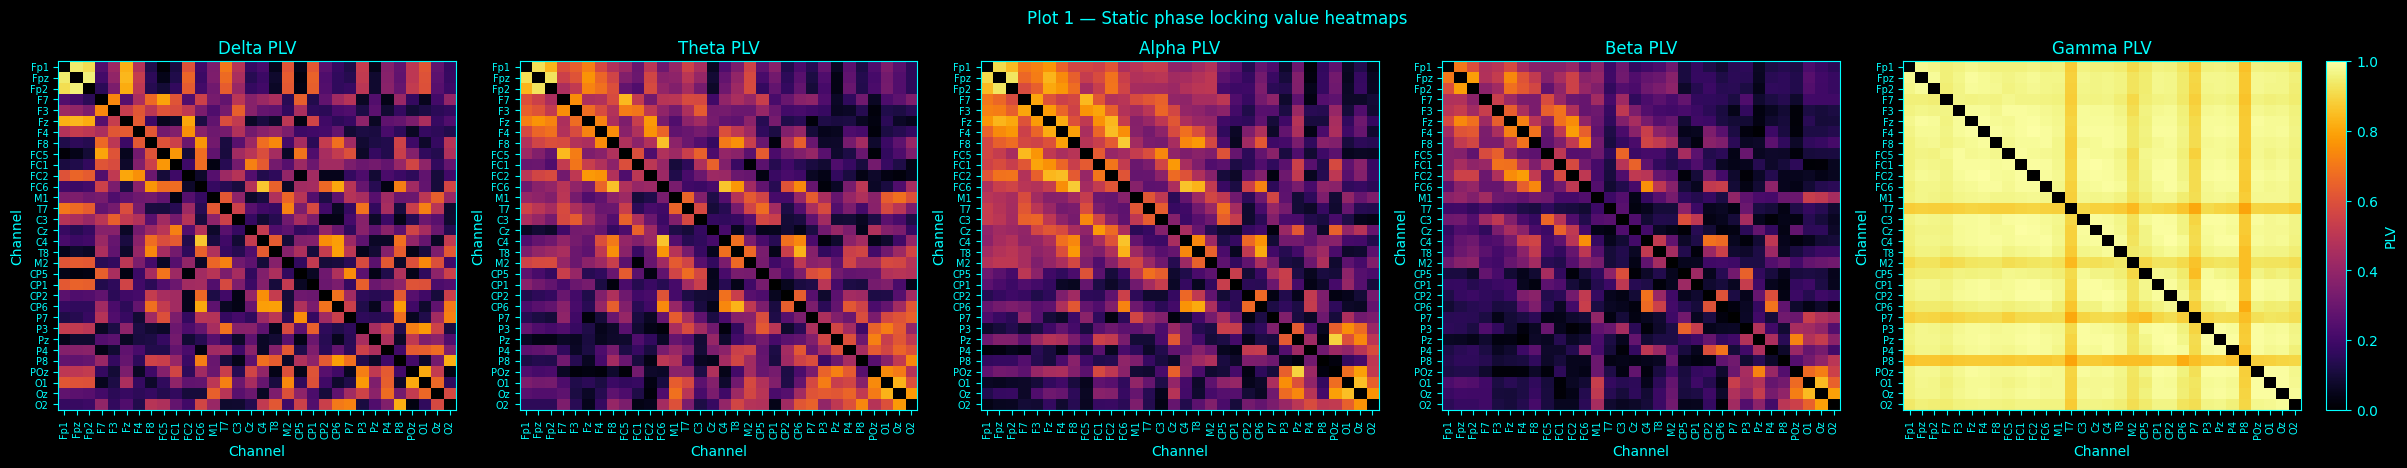

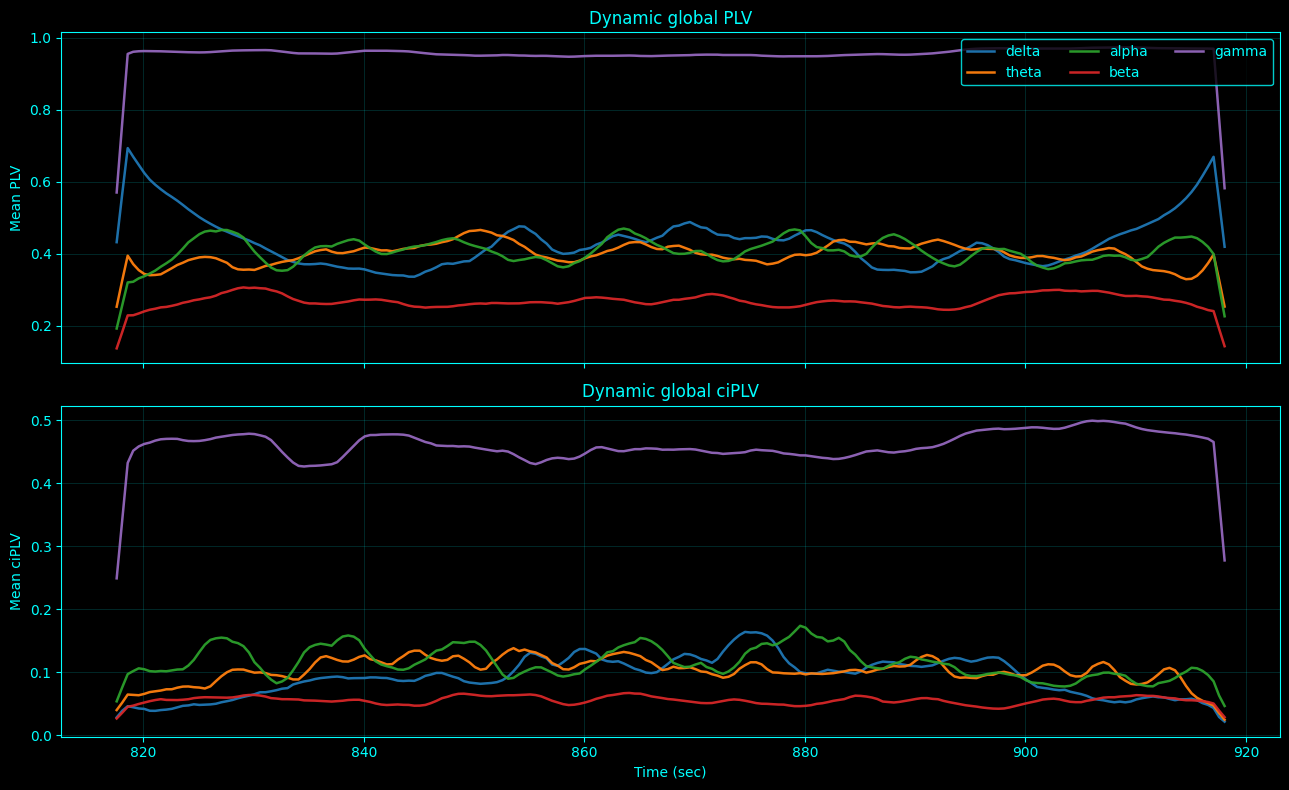

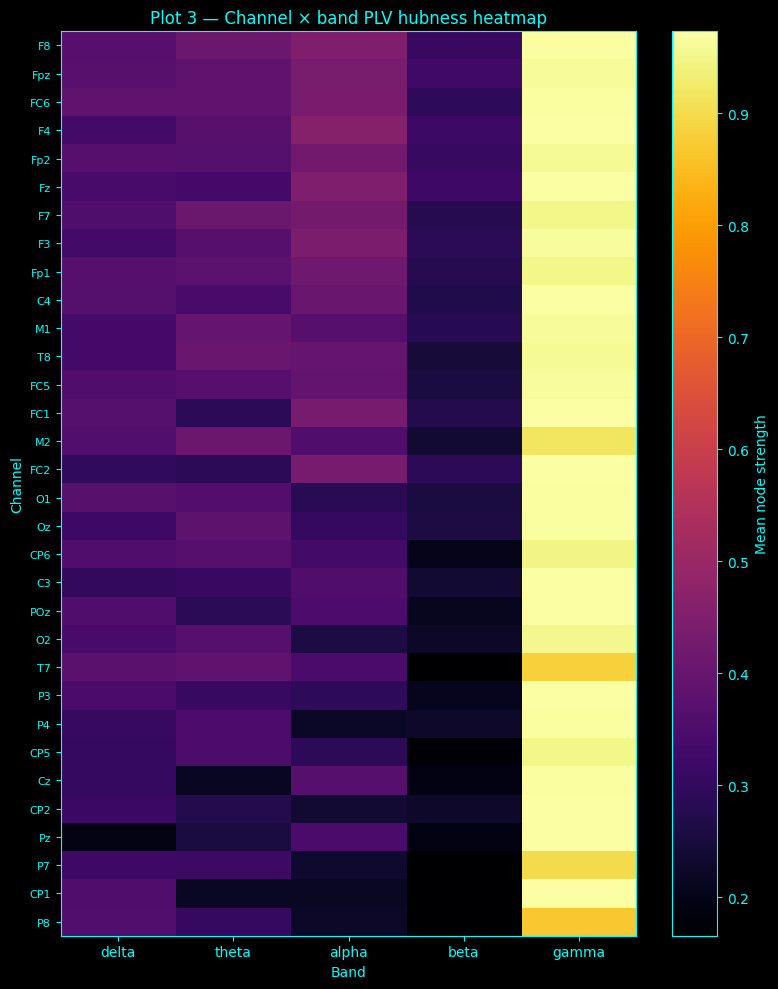

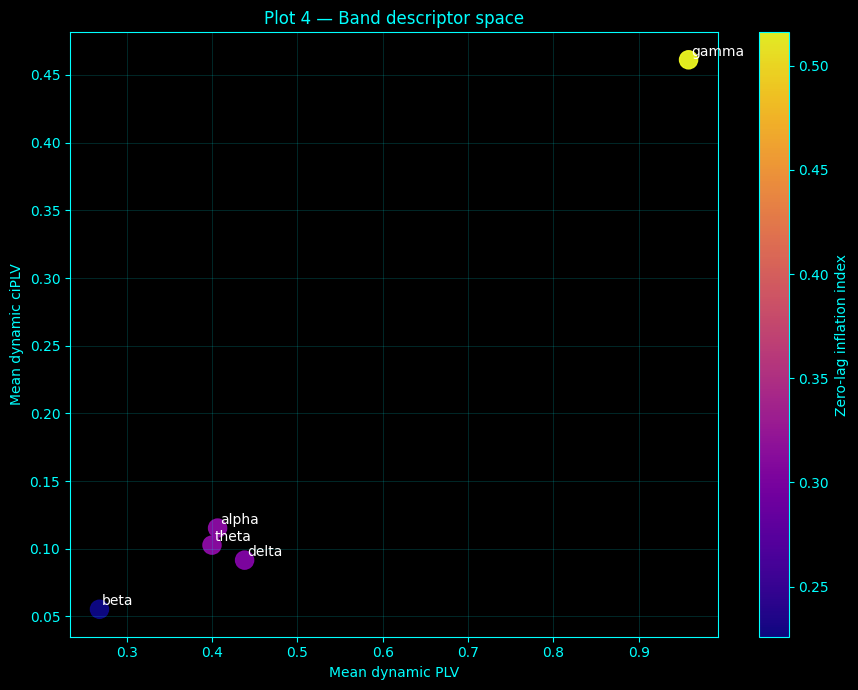

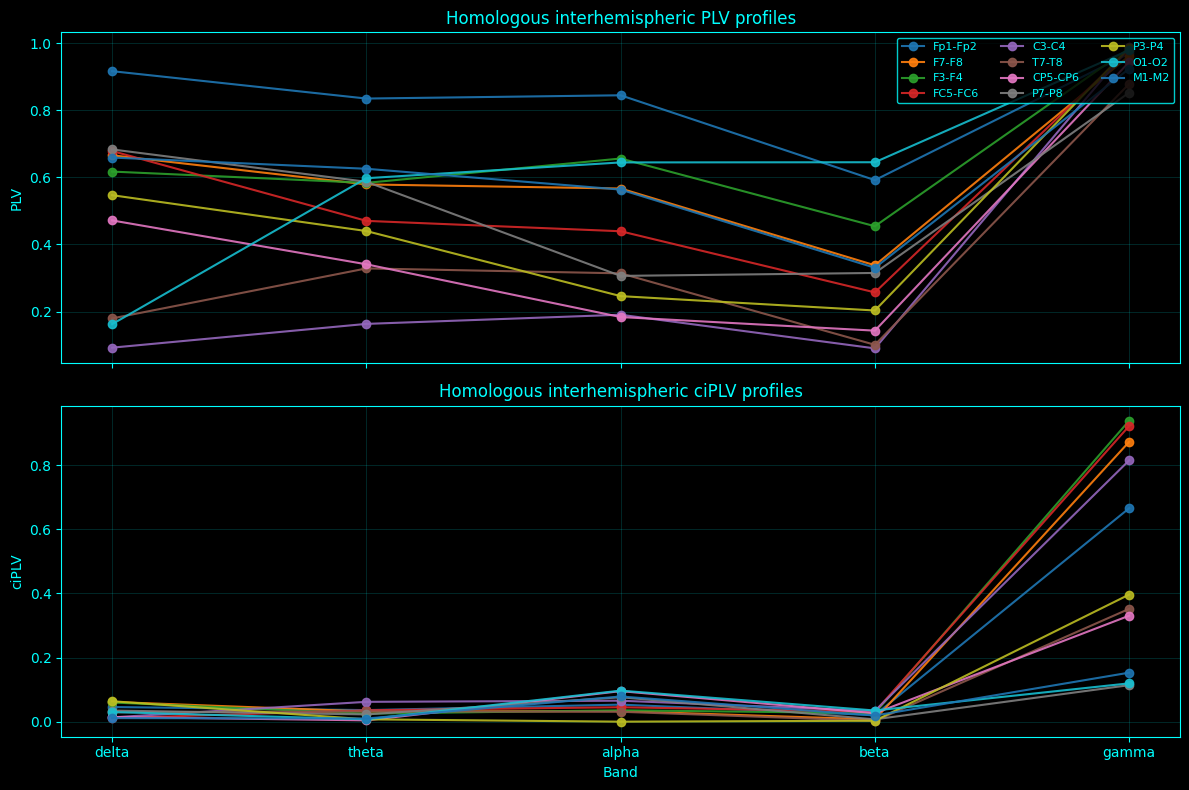


Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_band_summary.csv
Saved homologous-pair CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_homologous_pairs.csv
Saved band coordination CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_band_coordination.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_outputs.npz
Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_output_dict.npy
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_notes.txt
Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plots/plot1_static_plv_heatmaps.png
Saved plot 2: /home/a/projects/Complete-Neu

In [1]:

# ---- Shared runtime mode (full preserves this cell's original settings) ----
FAST_OPTION = globals().get("FAST_OPTION", "full")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: full, balanced, fast, ultra")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_phase_locking_value_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# -------------------------------------------------------
# THEORY / DESIGN
# -------------------------------------------------------
# Original script issue:
# broadband Hilbert phase on raw EEG is not a strong phase-synchrony definition.
# Phase is more interpretable after narrowband filtering.
#
# This rewrite upgrades the analysis into an exploratory phase-synchrony atlas:
#
# 1. Zero-phase bandpass filtering + Hilbert phase
# 2. Static PLV matrices by canonical band
# 3. Dynamic PLV over sliding windows
# 4. Static ciPLV sidecar (corrected imaginary PLV) as a lag-sensitive robustness view
# 5. Channel hubness / node strength by band
# 6. Homologous interhemispheric pair summaries
# 7. Novel exploratory descriptors:
#    - phase-lock attractor
#    - phase-lock volatility
#    - hub concentration
#    - anterior-posterior phase-lock bias
#    - zero-lag inflation index = PLV - ciPLV
#
# This is for exploratory expert research, not publishing, not benchmarking,
# and not scoring. PLV is treated as a descriptive synchrony statistic, not
# as a final connectivity claim.

apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

analysis_downsample_factor = {"full": 4, "balanced": 6, "fast": 8, "ultra": 12}[FAST_OPTION]
fs_analysis = sampling_rate / analysis_downsample_factor  # 250 Hz

frequency_bands = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
    "gamma": (30.0, 80.0),
}

dynamic_window_sec = 6.0
dynamic_step_sec = {"full": 0.5, "balanced": 0.75, "fast": 1, "ultra": 1.5}[FAST_OPTION]
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    "central":   ['FC5', 'FC1', 'FC2', 'FC6', 'C3', 'Cz', 'C4'],
    "posterior": ['CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'],
}

homologous_pairs = [
    ("Fp1", "Fp2"),
    ("F7", "F8"),
    ("F3", "F4"),
    ("FC5", "FC6"),
    ("C3", "C4"),
    ("T7", "T8"),
    ("CP5", "CP6"),
    ("P7", "P8"),
    ("P3", "P4"),
    ("O1", "O2"),
    ("M1", "M2"),
]

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def upper_triangle_values(mat):
    iu = np.triu_indices_from(mat, k=1)
    vals = mat[iu]
    return vals[np.isfinite(vals)]

def bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    if not (low < high):
        raise ValueError(f"Invalid band {lowcut}-{highcut} Hz for fs={fs}")
    return signal.butter(order, [low, high], btype="bandpass", output="sos")

def compute_band_phase(segment, fs, band):
    lowcut, highcut = band
    sos = bandpass_sos(lowcut, highcut, fs, order=4)

    n_samples, n_channels = segment.shape
    phases = np.full((n_samples, n_channels), np.nan, dtype=float)

    for ch in range(n_channels):
        y = signal.sosfiltfilt(sos, segment[:, ch])
        analytic = signal.hilbert(y)
        phases[:, ch] = np.angle(analytic)

    return phases

def phase_coupling_matrices(phases_txc):
    """
    Returns:
      plv   = |E[e^{i dphi}]|
      ciplv = |Im(E[e^{i dphi}])| / sqrt(1 - Re(E[e^{i dphi}])^2)

    ciPLV is included as a lag-sensitive sidecar to reduce zero-lag inflation.
    """
    phases_txc = np.asarray(phases_txc, dtype=float)
    mask_rows = np.all(np.isfinite(phases_txc), axis=1)
    phases_txc = phases_txc[mask_rows]

    n_t, n_ch = phases_txc.shape
    if n_t < 3:
        plv = np.full((n_ch, n_ch), np.nan, dtype=float)
        ciplv = np.full((n_ch, n_ch), np.nan, dtype=float)
        return plv, ciplv

    U = np.exp(1j * phases_txc)  # time x channels
    Z = (np.conjugate(U).T @ U) / n_t  # channels x channels, complex phase locking operator

    plv = np.abs(Z)

    reZ = np.real(Z)
    imZ = np.imag(Z)
    denom = np.sqrt(np.maximum(1.0 - reZ ** 2, eps))
    ciplv = np.abs(imZ) / denom

    np.fill_diagonal(plv, np.nan)
    np.fill_diagonal(ciplv, np.nan)

    return plv, ciplv

def dynamic_phase_coupling(phases, fs, window_sec=6.0, step_sec=0.5):
    n_samples, n_channels = phases.shape
    win = int(round(window_sec * fs))
    step = int(round(step_sec * fs))
    half = win // 2

    centers = np.arange(half, n_samples - half + 1, step, dtype=int)
    n_t = len(centers)

    dyn_global_plv = np.full(n_t, np.nan, dtype=float)
    dyn_global_ciplv = np.full(n_t, np.nan, dtype=float)

    for t_i, c in enumerate(centers):
        start = c - half
        stop = c + half
        chunk = phases[start:stop, :]

        plv_mat, ciplv_mat = phase_coupling_matrices(chunk)

        plv_vals = upper_triangle_values(plv_mat)
        ciplv_vals = upper_triangle_values(ciplv_mat)

        if len(plv_vals) > 0:
            dyn_global_plv[t_i] = np.nanmean(plv_vals)
        if len(ciplv_vals) > 0:
            dyn_global_ciplv[t_i] = np.nanmean(ciplv_vals)

    times_sec_rel = centers / fs
    return times_sec_rel, dyn_global_plv, dyn_global_ciplv

def node_strength_from_matrix(mat):
    mat = np.asarray(mat, dtype=float)
    n = mat.shape[0]
    out = np.full(n, np.nan, dtype=float)
    for i in range(n):
        row = np.delete(mat[i, :], i)
        row = row[np.isfinite(row)]
        if len(row) == 0:
            continue
        out[i] = np.mean(row)
    return out

def roi_mean_strength(strength_vec, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.nan
    vals = np.asarray(strength_vec, dtype=float)[idx]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))

def hub_concentration(strength_vec):
    x = np.asarray(strength_vec, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    x = x - np.min(x)
    if np.sum(x) <= eps:
        return 0.0
    p = x / np.sum(x)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    return float(1.0 - H / (Hmax + eps))

def synchrony_attractor_and_entropy(series, bins=40):
    x = np.asarray(series, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.array([]), np.array([])
    hist, edges = np.histogram(x, bins=bins)
    hist = hist.astype(float)
    hist = hist / (np.sum(hist) + eps)
    centers = 0.5 * (edges[:-1] + edges[1:])
    attractor = float(centers[np.argmax(hist)])
    positive = hist[hist > 0]
    H = -np.sum(positive * np.log(positive + eps))
    Hmax = np.log(len(hist) + eps)
    Hn = float(H / (Hmax + eps))
    return attractor, Hn, centers, hist

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=analysis_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

for ch in range(segment_ds.shape[1]):
    segment_ds[:, ch] = preprocess_channel(
        segment_ds[:, ch],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

n_samples, n_channels = segment_ds.shape
time_sec_rel = np.arange(n_samples) / fs_analysis
time_sec_abs = start_time + time_sec_rel

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled segment shape: {segment_ds.shape}")
print(f"Analysis fs: {fs_analysis:.1f} Hz")

# -------------------------------------------------------
# CORE PLV ANALYSIS
# -------------------------------------------------------
band_names = list(frequency_bands.keys())
n_bands = len(band_names)

plv_static = np.full((n_channels, n_channels, n_bands), np.nan, dtype=float)
ciplv_static = np.full((n_channels, n_channels, n_bands), np.nan, dtype=float)

plv_node_strengths = np.full((n_channels, n_bands), np.nan, dtype=float)
ciplv_node_strengths = np.full((n_channels, n_bands), np.nan, dtype=float)

dynamic_global_plv_dict = {}
dynamic_global_ciplv_dict = {}
phase_dict = {}
summary_rows = []
homologous_rows = []

dynamic_time_sec_abs = None

for b_i, band_name in enumerate(band_names):
    band = frequency_bands[band_name]
    print(f"Processing band: {band_name} {band}")

    phases = compute_band_phase(segment_ds, fs_analysis, band)
    phase_dict[band_name] = phases

    static_plv, static_ciplv = phase_coupling_matrices(phases)
    plv_static[:, :, b_i] = static_plv
    ciplv_static[:, :, b_i] = static_ciplv

    plv_strength = node_strength_from_matrix(static_plv)
    ciplv_strength = node_strength_from_matrix(static_ciplv)

    plv_node_strengths[:, b_i] = plv_strength
    ciplv_node_strengths[:, b_i] = ciplv_strength

    dyn_time_sec_rel, dyn_global_plv, dyn_global_ciplv = dynamic_phase_coupling(
        phases,
        fs_analysis,
        window_sec=dynamic_window_sec,
        step_sec=dynamic_step_sec,
    )
    dynamic_time_sec_abs = start_time + dyn_time_sec_rel
    dynamic_global_plv_dict[band_name] = dyn_global_plv
    dynamic_global_ciplv_dict[band_name] = dyn_global_ciplv

    attractor, dyn_entropy, _, _ = synchrony_attractor_and_entropy(dyn_global_plv, bins=40)

    frontal_mean = roi_mean_strength(plv_strength, eeg_channel_names, roi_definitions["frontal"])
    central_mean = roi_mean_strength(plv_strength, eeg_channel_names, roi_definitions["central"])
    posterior_mean = roi_mean_strength(plv_strength, eeg_channel_names, roi_definitions["posterior"])

    anterior_posterior_bias = (
        frontal_mean - posterior_mean
        if np.isfinite(frontal_mean) and np.isfinite(posterior_mean)
        else np.nan
    )

    plv_vals = upper_triangle_values(static_plv)
    ciplv_vals = upper_triangle_values(static_ciplv)

    static_plv_mean = float(np.nanmean(plv_vals)) if len(plv_vals) > 0 else np.nan
    static_plv_std = float(np.nanstd(plv_vals)) if len(plv_vals) > 0 else np.nan

    static_ciplv_mean = float(np.nanmean(ciplv_vals)) if len(ciplv_vals) > 0 else np.nan
    static_ciplv_std = float(np.nanstd(ciplv_vals)) if len(ciplv_vals) > 0 else np.nan

    zero_lag_inflation = static_plv_mean - static_ciplv_mean if np.isfinite(static_plv_mean) and np.isfinite(static_ciplv_mean) else np.nan

    summary_rows.append({
        "band": band_name,
        "low_hz": band[0],
        "high_hz": band[1],
        "static_global_plv_mean": static_plv_mean,
        "static_global_plv_std": static_plv_std,
        "static_global_ciplv_mean": static_ciplv_mean,
        "static_global_ciplv_std": static_ciplv_std,
        "dynamic_global_plv_mean": float(np.nanmean(dyn_global_plv)),
        "dynamic_global_plv_std": float(np.nanstd(dyn_global_plv)),
        "dynamic_global_ciplv_mean": float(np.nanmean(dyn_global_ciplv)),
        "dynamic_global_ciplv_std": float(np.nanstd(dyn_global_ciplv)),
        "phase_lock_attractor": attractor,
        "phase_lock_entropy": dyn_entropy,
        "frontal_mean_node_strength": frontal_mean,
        "central_mean_node_strength": central_mean,
        "posterior_mean_node_strength": posterior_mean,
        "anterior_posterior_bias": anterior_posterior_bias,
        "hub_concentration": hub_concentration(plv_strength),
        "zero_lag_inflation_index": zero_lag_inflation,
    })

    for ch_l, ch_r in homologous_pairs:
        if ch_l in eeg_channel_names and ch_r in eeg_channel_names:
            i = eeg_channel_names.index(ch_l)
            j = eeg_channel_names.index(ch_r)
            homologous_rows.append({
                "band": band_name,
                "channel_left": ch_l,
                "channel_right": ch_r,
                "plv": static_plv[i, j],
                "ciplv": static_ciplv[i, j],
            })

summary_df = pd.DataFrame(summary_rows)
homologous_df = pd.DataFrame(homologous_rows)

# -------------------------------------------------------
# SECOND-ORDER EXPLORATORY DESCRIPTORS
# -------------------------------------------------------
band_coord_rows = []
for i, b1 in enumerate(band_names):
    for j, b2 in enumerate(band_names):
        if j <= i:
            continue

        s1 = dynamic_global_plv_dict[b1]
        s2 = dynamic_global_plv_dict[b2]
        mask = np.isfinite(s1) & np.isfinite(s2)
        r_plv = np.corrcoef(s1[mask], s2[mask])[0, 1] if np.sum(mask) >= 3 else np.nan

        c1 = dynamic_global_ciplv_dict[b1]
        c2 = dynamic_global_ciplv_dict[b2]
        mask2 = np.isfinite(c1) & np.isfinite(c2)
        r_ciplv = np.corrcoef(c1[mask2], c2[mask2])[0, 1] if np.sum(mask2) >= 3 else np.nan

        band_coord_rows.append({
            "band_1": b1,
            "band_2": b2,
            "dynamic_global_plv_correlation": r_plv,
            "dynamic_global_ciplv_correlation": r_ciplv,
        })

band_coord_df = pd.DataFrame(band_coord_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_csv_path = os.path.join(out_dir, "plv_band_summary.csv")
homologous_csv_path = os.path.join(out_dir, "plv_homologous_pairs.csv")
band_coord_csv_path = os.path.join(out_dir, "plv_band_coordination.csv")
npz_path = os.path.join(out_dir, "plv_outputs.npz")
dict_npy_path = os.path.join(out_dir, "plv_output_dict.npy")
notes_txt_path = os.path.join(out_dir, "plv_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_static_plv_heatmaps.png")
plot2_path = os.path.join(plots_dir, "plot2_dynamic_global_plv_and_ciplv.png")
plot3_path = os.path.join(plots_dir, "plot3_channel_band_hubness_heatmap.png")
plot4_path = os.path.join(plots_dir, "plot4_band_descriptor_space.png")
plot5_path = os.path.join(plots_dir, "plot5_homologous_pair_profiles.png")

summary_df.to_csv(summary_csv_path, index=False)
homologous_df.to_csv(homologous_csv_path, index=False)
band_coord_df.to_csv(band_coord_csv_path, index=False)

np.savez_compressed(
    npz_path,
    plv_static=plv_static,
    ciplv_static=ciplv_static,
    plv_node_strengths=plv_node_strengths,
    ciplv_node_strengths=ciplv_node_strengths,
    dynamic_time_sec_abs=dynamic_time_sec_abs,
    dynamic_time_sec_rel=dynamic_time_sec_abs - start_time,
    channel_names=np.array(eeg_channel_names, dtype=object),
    band_names=np.array(band_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    analysis_sampling_rate=fs_analysis,
    analysis_downsample_factor=analysis_downsample_factor,
)

output_dict = {
    "plv_static": plv_static,
    "ciplv_static": ciplv_static,
    "plv_node_strengths": plv_node_strengths,
    "ciplv_node_strengths": ciplv_node_strengths,
    "dynamic_time_sec_abs": dynamic_time_sec_abs,
    "dynamic_global_plv_dict": dynamic_global_plv_dict,
    "dynamic_global_ciplv_dict": dynamic_global_ciplv_dict,
    "summary_df": summary_df,
    "homologous_df": homologous_df,
    "band_coord_df": band_coord_df,
}
np.save(dict_npy_path, output_dict, allow_pickle=True)

top_alpha_idx = np.argsort(plv_node_strengths[:, band_names.index("alpha")])[::-1][:5]
top_beta_idx = np.argsort(plv_node_strengths[:, band_names.index("beta")])[::-1][:5]

with open(notes_txt_path, "w") as f:
    f.write("Exploratory phase locking value (PLV) atlas\n")
    f.write("===========================================\n\n")
    f.write("Intent:\n")
    f.write("This pass upgrades a simple broadband PLV matrix into a multiband phase-synchrony exploration.\n")
    f.write("It is for exploratory expert research, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Major upgrades relative to the original script:\n")
    f.write("1. Uses file paths only and the selected segment of interest.\n")
    f.write("2. Uses narrowband zero-phase filtering before Hilbert phase extraction.\n")
    f.write("3. Computes static PLV by band instead of broadband Hilbert phase on raw EEG.\n")
    f.write("4. Adds dynamic PLV trajectories over sliding windows.\n")
    f.write("5. Adds ciPLV as a lag-sensitive robustness sidecar.\n")
    f.write("6. Adds node-strength hubness by band.\n")
    f.write("7. Adds homologous interhemispheric pair summaries.\n")
    f.write("8. Adds phase-lock attractor, volatility, and zero-lag inflation descriptors.\n\n")
    f.write("Conceptual note:\n")
    f.write("PLV is sensitive to zero-lag and common-source structure. ciPLV is included as an exploratory guardrail,\n")
    f.write("not as a final correction. The pair PLV minus ciPLV gap can be interpreted as a rough zero-lag inflation tendency.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Analysis fs: {fs_analysis:.1f} Hz\n")
    f.write(f"Dynamic window: {dynamic_window_sec:.2f} sec\n")
    f.write(f"Dynamic step: {dynamic_step_sec:.2f} sec\n\n")

    f.write("Top alpha-hub channels:\n")
    for idx in top_alpha_idx:
        f.write(f"  {eeg_channel_names[idx]}: alpha_strength={plv_node_strengths[idx, band_names.index('alpha')]:.4f}\n")

    f.write("\nTop beta-hub channels:\n")
    for idx in top_beta_idx:
        f.write(f"  {eeg_channel_names[idx]}: beta_strength={plv_node_strengths[idx, band_names.index('beta')]:.4f}\n")

# -------------------------------------------------------
# PLOT 1 — STATIC PLV HEATMAPS
# -------------------------------------------------------
fig1, axes = plt.subplots(1, n_bands, figsize=(4.8 * n_bands + 1.2, 5.2), facecolor=BG)
axes = np.atleast_1d(axes)

cmap1 = plt.cm.inferno.copy()
cmap1.set_bad(color=BG)

vmin = 0.0
vmax = 1.0
last_im = None

for b_i, band_name in enumerate(band_names):
    ax = axes[b_i]
    style_ax(ax, heatmap=True)

    mat = np.ma.masked_invalid(plv_static[:, :, b_i])
    last_im = ax.imshow(
        mat,
        cmap=cmap1,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_title(f"{band_name.capitalize()} PLV")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Channel")
    ax.set_xticks(np.arange(n_channels))
    ax.set_xticklabels(eeg_channel_names, rotation=90, fontsize=7)
    ax.set_yticks(np.arange(n_channels))
    ax.set_yticklabels(eeg_channel_names, fontsize=7)

# leave room on the right for a dedicated colorbar axis
fig1.subplots_adjust(left=0.04, right=0.93, bottom=0.18, top=0.85, wspace=0.16)

# dedicated colorbar axis: [left, bottom, width, height] in figure coords
cax = fig1.add_axes([0.94, 0.18, 0.008, 0.67])
cbar1 = fig1.colorbar(last_im, cax=cax)
cbar1.set_label("PLV", color=ACCENT)
cbar1.outline.set_edgecolor(ACCENT)
cbar1.ax.tick_params(color=ACCENT)
for label in cbar1.ax.get_yticklabels():
    label.set_color(ACCENT)

fig1.suptitle("Plot 1 — Static phase locking value heatmaps", color=ACCENT, y=0.95)
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — DYNAMIC GLOBAL PLV / ciPLV
# -------------------------------------------------------
fig2, axes2 = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
axes2 = np.atleast_1d(axes2)

for ax in axes2:
    style_ax(ax)

for band_name in band_names:
    axes2[0].plot(
        dynamic_time_sec_abs,
        smooth_1d(dynamic_global_plv_dict[band_name], win=5),
        linewidth=1.8,
        alpha=0.95,
        label=band_name,
    )

for band_name in band_names:
    axes2[1].plot(
        dynamic_time_sec_abs,
        smooth_1d(dynamic_global_ciplv_dict[band_name], win=5),
        linewidth=1.8,
        alpha=0.95,
        label=band_name,
    )

axes2[0].set_title("Dynamic global PLV")
axes2[0].set_ylabel("Mean PLV")
axes2[0].legend(loc="upper right", ncol=3)

axes2[1].set_title("Dynamic global ciPLV")
axes2[1].set_xlabel("Time (sec)")
axes2[1].set_ylabel("Mean ciPLV")

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — CHANNEL × BAND HUBNESS HEATMAP
# -------------------------------------------------------
channel_order = np.argsort(np.nanmean(plv_node_strengths, axis=1))[::-1]
ordered_channels = [eeg_channel_names[i] for i in channel_order]
hub_heat = plv_node_strengths[channel_order, :]

fig3, ax3 = plt.subplots(figsize=(8, 10), facecolor=BG)
style_ax(ax3, heatmap=True)

vmin3, vmax3 = percentile_limits(hub_heat, lo=2, hi=98)
if vmin3 is None or vmax3 is None:
    vmin3, vmax3 = 0.0, 1.0

im3 = ax3.imshow(
    hub_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin3,
    vmax=vmax3,
)

ax3.set_title("Plot 3 — Channel × band PLV hubness heatmap")
ax3.set_xlabel("Band")
ax3.set_ylabel("Channel")
ax3.set_xticks(np.arange(n_bands))
ax3.set_xticklabels(band_names)
ax3.set_yticks(np.arange(n_channels))
ax3.set_yticklabels(ordered_channels, fontsize=8)

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label("Mean node strength", color=ACCENT)
cbar3.outline.set_edgecolor(ACCENT)
cbar3.ax.tick_params(color=ACCENT)
for label in cbar3.ax.get_yticklabels():
    label.set_color(ACCENT)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — BAND DESCRIPTOR SPACE
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax4)

x = summary_df["dynamic_global_plv_mean"].values
y = summary_df["dynamic_global_ciplv_mean"].values
c = summary_df["zero_lag_inflation_index"].values

scatter = ax4.scatter(
    x,
    y,
    c=c,
    s=170,
    cmap="plasma",
    alpha=0.95,
)

for _, row in summary_df.iterrows():
    ax4.text(
        row["dynamic_global_plv_mean"] + 0.003,
        row["dynamic_global_ciplv_mean"] + 0.003,
        row["band"],
        color="white",
        fontsize=10,
    )

ax4.set_title("Plot 4 — Band descriptor space")
ax4.set_xlabel("Mean dynamic PLV")
ax4.set_ylabel("Mean dynamic ciPLV")

cbar4 = plt.colorbar(scatter, ax=ax4)
cbar4.set_label("Zero-lag inflation index", color=ACCENT)
cbar4.outline.set_edgecolor(ACCENT)
cbar4.ax.tick_params(color=ACCENT)
for label in cbar4.ax.get_yticklabels():
    label.set_color(ACCENT)

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — HOMOLOGOUS PAIR PROFILES
# -------------------------------------------------------
fig5, axes5 = plt.subplots(2, 1, figsize=(12, 8), facecolor=BG, sharex=True)
axes5 = np.atleast_1d(axes5)

for ax in axes5:
    style_ax(ax)

pair_labels = []
for ch_l, ch_r in homologous_pairs:
    sub = homologous_df[(homologous_df["channel_left"] == ch_l) & (homologous_df["channel_right"] == ch_r)]
    if len(sub) == 0:
        continue
    pair_labels.append(f"{ch_l}-{ch_r}")

    y_plv = [sub[sub["band"] == b]["plv"].iloc[0] if np.any(sub["band"] == b) else np.nan for b in band_names]
    y_ciplv = [sub[sub["band"] == b]["ciplv"].iloc[0] if np.any(sub["band"] == b) else np.nan for b in band_names]

    axes5[0].plot(band_names, y_plv, marker="o", linewidth=1.5, alpha=0.9, label=f"{ch_l}-{ch_r}")
    axes5[1].plot(band_names, y_ciplv, marker="o", linewidth=1.5, alpha=0.9, label=f"{ch_l}-{ch_r}")

axes5[0].set_title("Homologous interhemispheric PLV profiles")
axes5[0].set_ylabel("PLV")
axes5[0].legend(loc="upper right", ncol=3, fontsize=8)

axes5[1].set_title("Homologous interhemispheric ciPLV profiles")
axes5[1].set_ylabel("ciPLV")
axes5[1].set_xlabel("Band")

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"\nSaved summary CSV: {summary_csv_path}")
print(f"Saved homologous-pair CSV: {homologous_csv_path}")
print(f"Saved band coordination CSV: {band_coord_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved dict NPY: {dict_npy_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Phase-locking value</h3><p>PLV measures concentration of instantaneous phase differences across samples, trials, or windows. It is insensitive to amplitude and equals one only when the phase difference is constant over the averaging ensemble.</p><p><b>Cell role.</b> This code applies that theory to the notebook's existing EEG-derived data and preserves the surrounding notebook's plotting/output conventions. Numerical shortcuts selected by a speed mode change sampling density, iteration counts, or visualization resolution; they do not change the defining formula above.</p></div>

$$\\operatorname{PLV}=\\left|\\frac1N\\sum_{n=1}^{N}e^{i(\\phi_x[n]-\\phi_y[n])}\\right|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled segment shape: (26736, 32)
Analysis fs: 250.0 Hz
Posterior consensus alpha peak: 10.803 Hz
Individualized alpha band: [9.303, 12.303] Hz

Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_summary.csv
Saved trajectory CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_trajectory.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_outputs.npz
Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_output_dict.npy
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_notes.txt


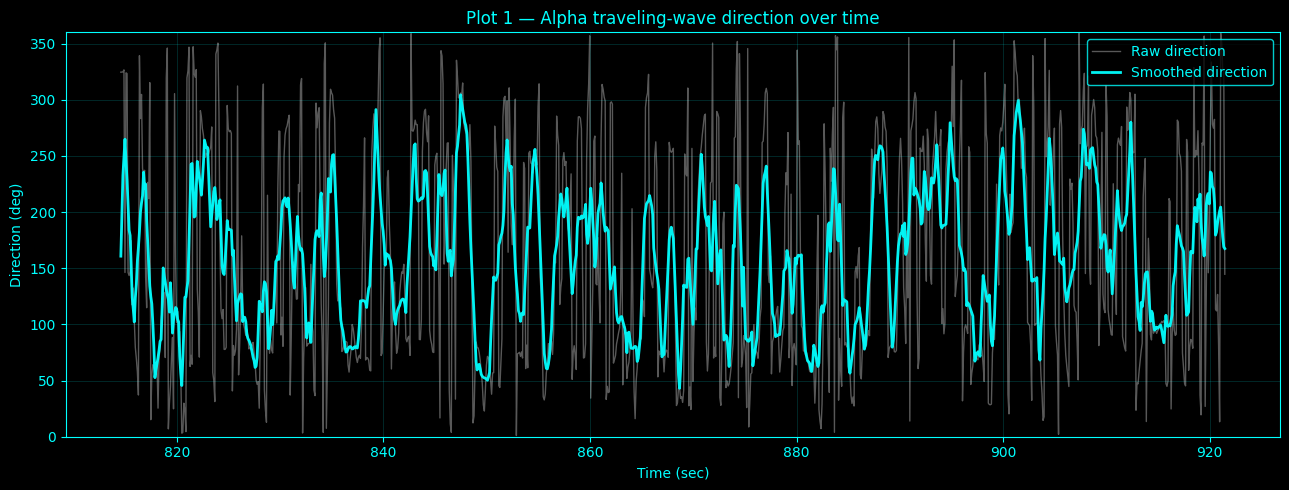

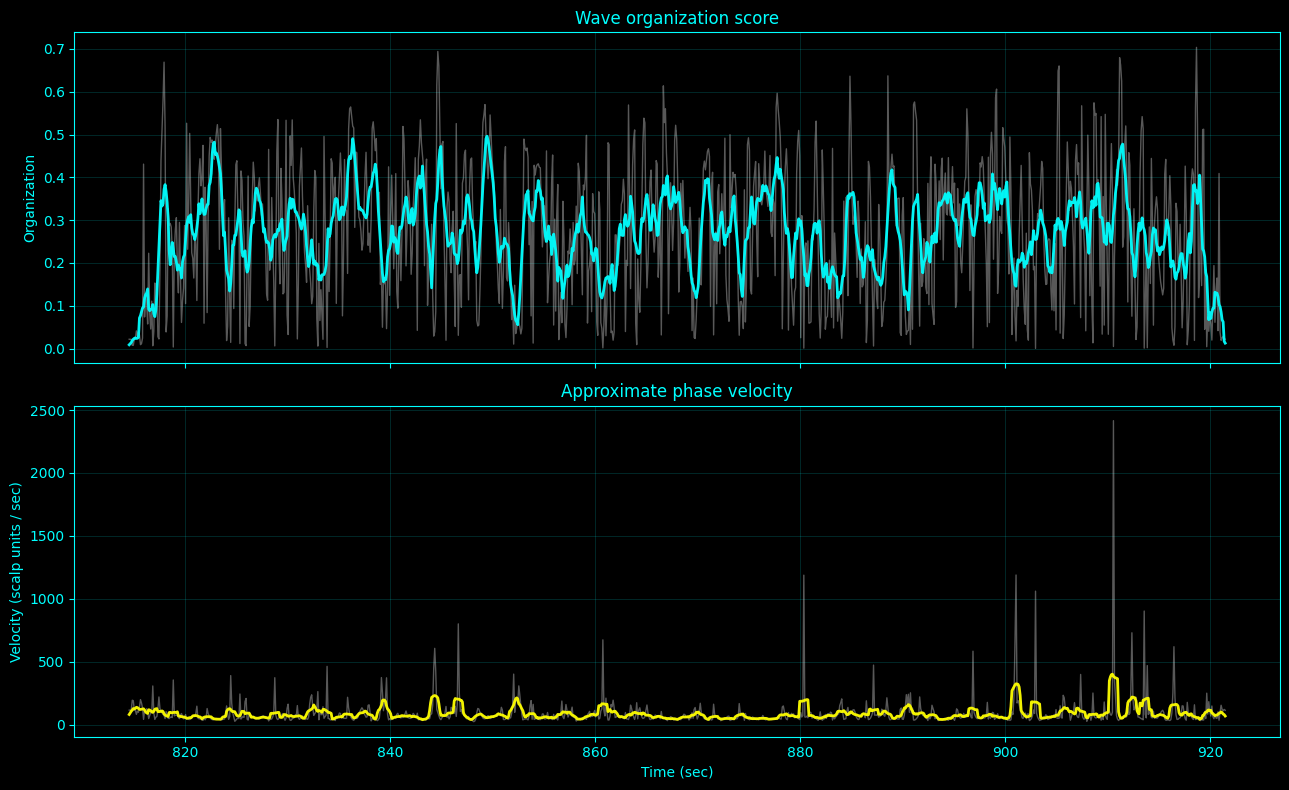

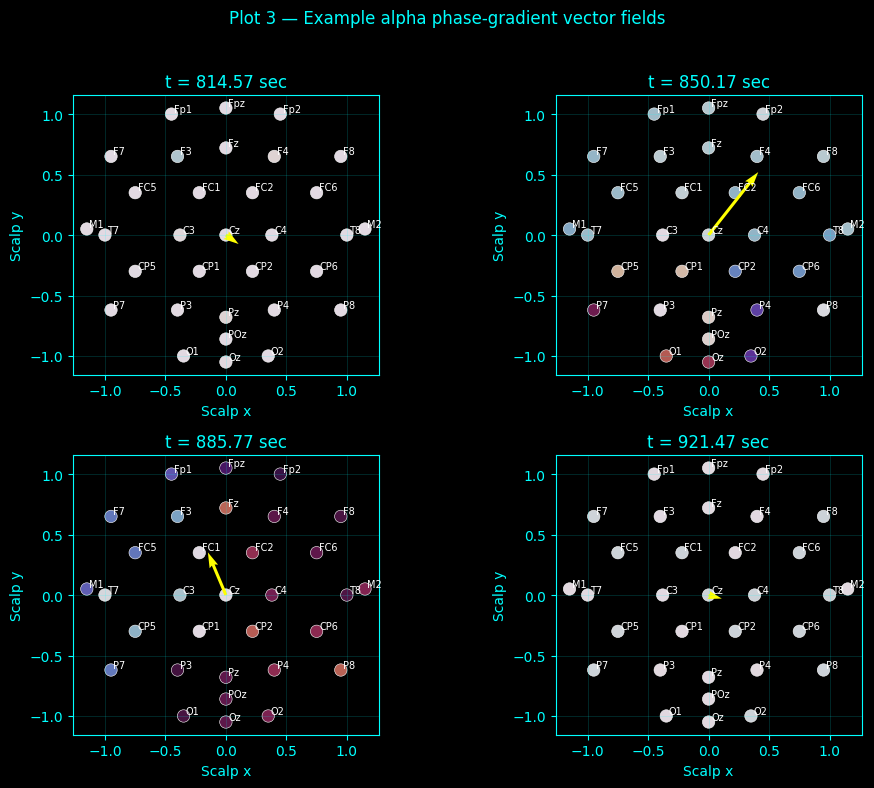

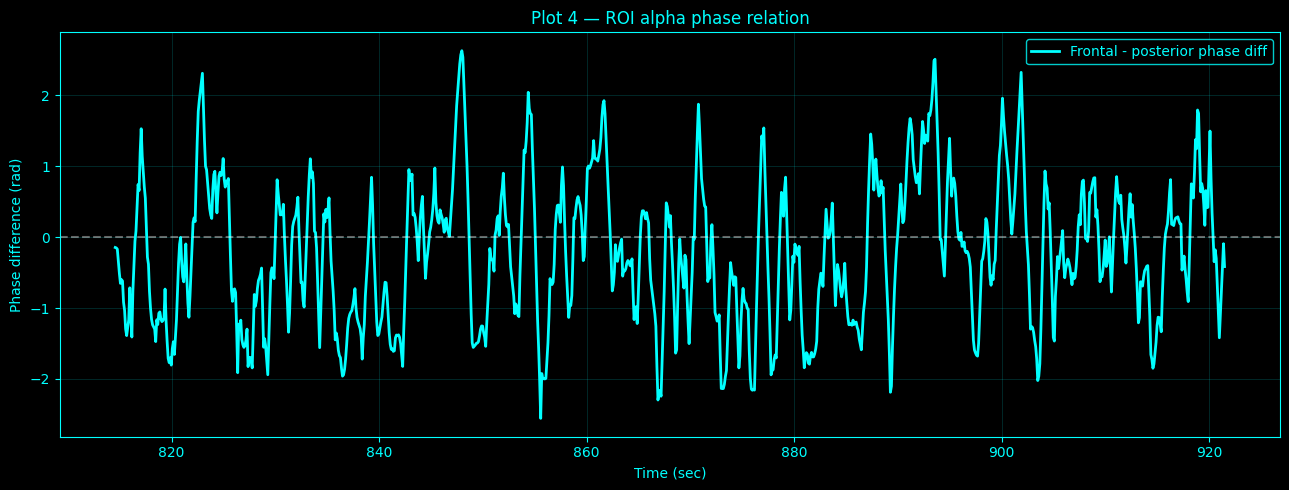

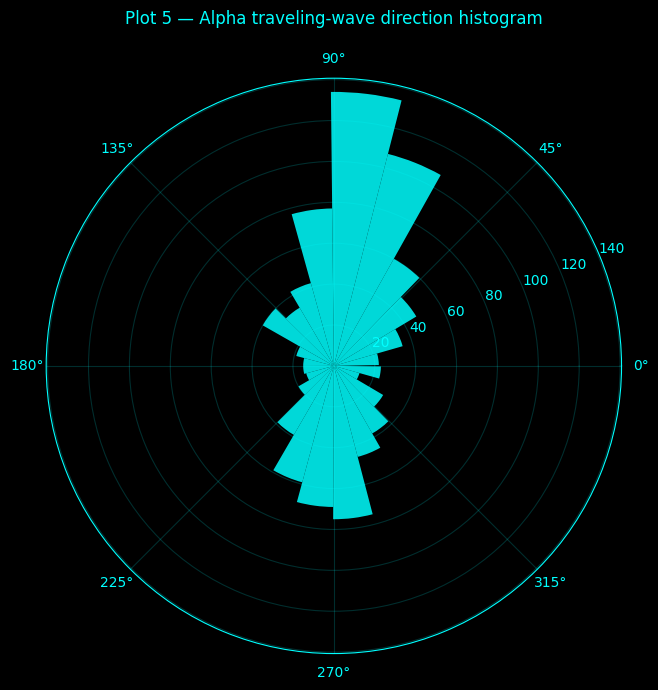

Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot1_alpha_phase_gradient_direction_over_time.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot2_wave_organization_and_speed.png
Saved plot 3: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot3_phase_gradient_vector_field_examples.png
Saved plot 4: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot4_roi_phase_relations.png
Saved plot 5: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot5_directional_polar_histogram.png
Done.


In [1]:

# ---- Shared runtime mode (full preserves this cell's original settings) ----
FAST_OPTION = globals().get("FAST_OPTION", "full")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: full, balanced, fast, ultra")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_alpha_traveling_wave_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

analysis_downsample_factor = {"full": 4, "balanced": 6, "fast": 8, "ultra": 12}[FAST_OPTION]
fs_analysis = sampling_rate / analysis_downsample_factor  # 250 Hz

# Dynamic sampling for summaries / plots
summary_step_sec = {"full": 0.1, "balanced": 0.15, "fast": 0.2, "ultra": 0.3}[FAST_OPTION]
# Alpha estimation / wave tracking
alpha_search_band = (7.0, 13.0)
alpha_halfwidth_hz = 1.5
posterior_alpha_channels = ["P3", "Pz", "P4", "POz", "O1", "Oz", "O2"]
min_valid_channels_per_time = 16

# smoothing for wave metrics
metric_smooth_win = 9

# -------------------------------------------------------
# CHANNELS + APPROXIMATE 10-20 POSITIONS
# 2D scalp coordinates, exploratory only
# x: left(-) to right(+)
# y: posterior(-) to anterior(+)
# -------------------------------------------------------
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

channel_xy = {
    "Fp1": (-0.45,  1.00), "Fpz": ( 0.00,  1.05), "Fp2": ( 0.45,  1.00),
    "F7":  (-0.95,  0.65), "F3":  (-0.40,  0.65), "Fz":  ( 0.00,  0.72), "F4":  ( 0.40,  0.65), "F8":  ( 0.95,  0.65),
    "FC5": (-0.75,  0.35), "FC1": (-0.22,  0.35), "FC2": ( 0.22,  0.35), "FC6": ( 0.75,  0.35),
    "M1":  (-1.15,  0.05), "T7":  (-1.00,  0.00), "C3":  (-0.38,  0.00), "Cz":  ( 0.00,  0.00), "C4":  ( 0.38,  0.00), "T8":  ( 1.00,  0.00), "M2":  ( 1.15,  0.05),
    "CP5": (-0.75, -0.30), "CP1": (-0.22, -0.30), "CP2": ( 0.22, -0.30), "CP6": ( 0.75, -0.30),
    "P7":  (-0.95, -0.62), "P3":  (-0.40, -0.62), "Pz":  ( 0.00, -0.68), "P4":  ( 0.40, -0.62), "P8":  ( 0.95, -0.62),
    "POz": ( 0.00, -0.86),
    "O1":  (-0.35, -1.00), "Oz":  ( 0.00, -1.05), "O2":  ( 0.35, -1.00),
}

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    "central":   ['FC5', 'FC1', 'FC2', 'FC6', 'C3', 'Cz', 'C4'],
    "posterior": ['CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'],
}

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    if not (low < high):
        raise ValueError(f"Invalid band {lowcut}-{highcut} Hz for fs={fs}")
    return signal.butter(order, [low, high], btype="bandpass", output="sos")

def compute_welch_psd(y, fs, window_sec=4.0, overlap=0.5, nfft=8192):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)
    f, pxx = signal.welch(
        y, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap,
        detrend="constant", scaling="density", nfft=nfft
    )
    return f, pxx

def robust_alpha_peak(freqs_hz, psd_1d, band=(7.0, 13.0)):
    mask = (freqs_hz >= band[0]) & (freqs_hz <= band[1]) & np.isfinite(psd_1d)
    if np.sum(mask) < 5:
        return np.nan
    f = freqs_hz[mask]
    y = psd_1d[mask]
    idx = int(np.nanargmax(y))
    return float(f[idx])

def circular_mean(phases_rad):
    z = np.exp(1j * np.asarray(phases_rad, dtype=float))
    return np.angle(np.nanmean(z))

def wrap_to_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def phase_gradient_fit(phases, xs, ys):
    """
    Fits phi(x,y) = a*x + b*y + c to unwrapped phases around circular mean.
    Returns gradient vector [a,b], fit R^2-like score, and residual std.
    """
    phases = np.asarray(phases, dtype=float)
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    mask = np.isfinite(phases) & np.isfinite(xs) & np.isfinite(ys)
    if np.sum(mask) < 6:
        return np.array([np.nan, np.nan]), np.nan, np.nan

    phases = phases[mask]
    xs = xs[mask]
    ys = ys[mask]

    phi0 = circular_mean(phases)
    dphi = wrap_to_pi(phases - phi0)

    X = np.column_stack([xs, ys, np.ones_like(xs)])
    beta, _, _, _ = np.linalg.lstsq(X, dphi, rcond=None)
    pred = X @ beta
    resid = dphi - pred

    ss_res = np.sum((dphi - pred) ** 2)
    ss_tot = np.sum((dphi - np.mean(dphi)) ** 2) + eps
    r2 = 1.0 - ss_res / ss_tot

    grad = beta[:2]
    resid_std = float(np.std(resid))
    return grad, float(r2), resid_std

def direction_deg_from_grad(grad_xy):
    gx, gy = grad_xy
    if not np.isfinite(gx) or not np.isfinite(gy):
        return np.nan
    # direction of increasing phase; propagation direction is opposite
    ang = np.degrees(np.arctan2(-gy, -gx))
    if ang < 0:
        ang += 360.0
    return float(ang)

def wave_metrics_from_grad(grad_xy, freq_hz):
    gx, gy = grad_xy
    if not np.isfinite(gx) or not np.isfinite(gy) or not np.isfinite(freq_hz):
        return np.nan, np.nan, np.nan

    k = float(np.sqrt(gx**2 + gy**2))   # rad / scalp-unit
    if k < 1e-8:
        return 0.0, np.inf, np.inf

    wavelength = float(2.0 * np.pi / k)        # scalp units / cycle
    speed = float((2.0 * np.pi * freq_hz) / k) # scalp units / sec
    return k, wavelength, speed

def roi_mean(values, names, roi_channels):
    idx = [names.index(ch) for ch in roi_channels if ch in names]
    if len(idx) == 0:
        return np.nan
    vals = np.asarray(values, dtype=float)[idx]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=analysis_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

for ch in range(segment_ds.shape[1]):
    segment_ds[:, ch] = preprocess_channel(
        segment_ds[:, ch],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

n_samples, n_channels = segment_ds.shape
time_sec_rel = np.arange(n_samples) / fs_analysis
time_sec_abs = start_time + time_sec_rel

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled segment shape: {segment_ds.shape}")
print(f"Analysis fs: {fs_analysis:.1f} Hz")

# -------------------------------------------------------
# INDIVIDUALIZED ALPHA BAND ESTIMATION
# -------------------------------------------------------
posterior_idx = [eeg_channel_names.index(ch) for ch in posterior_alpha_channels if ch in eeg_channel_names]
posterior_mean = np.nanmean(segment_ds[:, posterior_idx], axis=1)

freqs_hz, pxx = compute_welch_psd(posterior_mean, fs_analysis, window_sec=4.0, overlap=0.5, nfft=8192)
alpha_peak_hz = robust_alpha_peak(freqs_hz, pxx, band=alpha_search_band)

if not np.isfinite(alpha_peak_hz):
    alpha_peak_hz = 10.0

alpha_band = (
    max(alpha_search_band[0], alpha_peak_hz - alpha_halfwidth_hz),
    min(alpha_search_band[1], alpha_peak_hz + alpha_halfwidth_hz),
)

print(f"Posterior consensus alpha peak: {alpha_peak_hz:.3f} Hz")
print(f"Individualized alpha band: [{alpha_band[0]:.3f}, {alpha_band[1]:.3f}] Hz")

# -------------------------------------------------------
# NARROWBAND ALPHA ANALYTIC SIGNAL
# -------------------------------------------------------
sos_alpha = bandpass_sos(alpha_band[0], alpha_band[1], fs_analysis, order=4)

alpha_phase = np.full((n_samples, n_channels), np.nan, dtype=float)
alpha_amp = np.full((n_samples, n_channels), np.nan, dtype=float)

for ch_i in range(n_channels):
    y = signal.sosfiltfilt(sos_alpha, segment_ds[:, ch_i])
    analytic = signal.hilbert(y)
    alpha_phase[:, ch_i] = np.angle(analytic)
    alpha_amp[:, ch_i] = np.abs(analytic)

# -------------------------------------------------------
# PHASE-GRADIENT TRAVELING-WAVE ANALYSIS
# -------------------------------------------------------
xs = np.array([channel_xy[ch][0] for ch in eeg_channel_names], dtype=float)
ys = np.array([channel_xy[ch][1] for ch in eeg_channel_names], dtype=float)

step = max(int(round(summary_step_sec * fs_analysis)), 1)
summary_idx = np.arange(0, n_samples, step, dtype=int)
summary_time_sec_abs = start_time + summary_idx / fs_analysis

grad_x = np.full(len(summary_idx), np.nan, dtype=float)
grad_y = np.full(len(summary_idx), np.nan, dtype=float)
wave_dir_deg = np.full(len(summary_idx), np.nan, dtype=float)
wave_k = np.full(len(summary_idx), np.nan, dtype=float)
wave_lambda = np.full(len(summary_idx), np.nan, dtype=float)
wave_speed = np.full(len(summary_idx), np.nan, dtype=float)
fit_r2 = np.full(len(summary_idx), np.nan, dtype=float)
resid_std = np.full(len(summary_idx), np.nan, dtype=float)
organization_score = np.full(len(summary_idx), np.nan, dtype=float)

for t_i, s_idx in enumerate(summary_idx):
    phi_t = alpha_phase[s_idx, :]
    amp_t = alpha_amp[s_idx, :]

    valid = np.isfinite(phi_t) & np.isfinite(amp_t)
    if np.sum(valid) < min_valid_channels_per_time:
        continue

    # weighted selection: keep stronger-amplitude channels for more stable phase field
    amp_thr = np.nanpercentile(amp_t[valid], 25.0)
    keep = valid & (amp_t >= amp_thr)

    if np.sum(keep) < min_valid_channels_per_time:
        keep = valid

    grad, r2, rs = phase_gradient_fit(phi_t[keep], xs[keep], ys[keep])

    grad_x[t_i] = grad[0]
    grad_y[t_i] = grad[1]
    fit_r2[t_i] = r2
    resid_std[t_i] = rs

    direction = direction_deg_from_grad(grad)
    k, wavelength, speed = wave_metrics_from_grad(grad, alpha_peak_hz)

    wave_dir_deg[t_i] = direction
    wave_k[t_i] = k
    wave_lambda[t_i] = wavelength
    wave_speed[t_i] = speed

    # simple organization score favors strong planar fit and low residual
    organization_score[t_i] = float(max(r2, 0.0) / (1.0 + rs)) if np.isfinite(r2) and np.isfinite(rs) else np.nan

# smooth metric trajectories
grad_x_s = smooth_1d(grad_x, win=metric_smooth_win)
grad_y_s = smooth_1d(grad_y, win=metric_smooth_win)
wave_k_s = smooth_1d(wave_k, win=metric_smooth_win)
wave_lambda_s = smooth_1d(wave_lambda, win=metric_smooth_win)
wave_speed_s = smooth_1d(wave_speed, win=metric_smooth_win)
fit_r2_s = smooth_1d(fit_r2, win=metric_smooth_win)
organization_score_s = smooth_1d(organization_score, win=metric_smooth_win)

# -------------------------------------------------------
# ROI PHASE REFERENCE TRAJECTORIES
# -------------------------------------------------------
roi_phase_traces = {}
for roi_name, roi_channels in roi_definitions.items():
    idx = [eeg_channel_names.index(ch) for ch in roi_channels if ch in eeg_channel_names]
    z = np.exp(1j * alpha_phase[:, idx])
    roi_phase_traces[roi_name] = np.angle(np.nanmean(z, axis=1))

# anterior-posterior lag proxy
front_phase = roi_phase_traces["frontal"][summary_idx]
post_phase = roi_phase_traces["posterior"][summary_idx]
front_post_phase_diff = wrap_to_pi(front_phase - post_phase)

# -------------------------------------------------------
# DESCRIPTIVE SUMMARIES
# -------------------------------------------------------
valid_dir = np.isfinite(wave_dir_deg)
if np.sum(valid_dir) > 0:
    mean_wave_dir_deg = float(np.degrees(np.angle(np.nanmean(np.exp(1j * np.radians(wave_dir_deg[valid_dir]))))))
    if mean_wave_dir_deg < 0:
        mean_wave_dir_deg += 360.0
else:
    mean_wave_dir_deg = np.nan

summary_df = pd.DataFrame([{
    "alpha_peak_hz": alpha_peak_hz,
    "alpha_band_low_hz": alpha_band[0],
    "alpha_band_high_hz": alpha_band[1],
    "mean_wave_direction_deg": mean_wave_dir_deg,
    "mean_wavenumber_rad_per_unit": float(np.nanmean(wave_k_s)),
    "mean_wavelength_scalp_units": float(np.nanmean(wave_lambda_s)),
    "mean_phase_velocity_units_per_sec": float(np.nanmean(wave_speed_s)),
    "mean_planar_fit_r2": float(np.nanmean(fit_r2_s)),
    "mean_residual_std_rad": float(np.nanmean(resid_std)),
    "mean_organization_score": float(np.nanmean(organization_score_s)),
    "wave_organization_volatility": float(np.nanstd(organization_score_s)),
    "frontal_minus_posterior_phase_bias_rad": float(np.nanmean(front_post_phase_diff)),
}])

trajectory_df = pd.DataFrame({
    "time_sec": summary_time_sec_abs,
    "grad_x": grad_x,
    "grad_y": grad_y,
    "grad_x_s": grad_x_s,
    "grad_y_s": grad_y_s,
    "wave_direction_deg": wave_dir_deg,
    "wavenumber_rad_per_unit": wave_k,
    "wavenumber_rad_per_unit_s": wave_k_s,
    "wavelength_scalp_units": wave_lambda,
    "wavelength_scalp_units_s": wave_lambda_s,
    "phase_velocity_units_per_sec": wave_speed,
    "phase_velocity_units_per_sec_s": wave_speed_s,
    "fit_r2": fit_r2,
    "fit_r2_s": fit_r2_s,
    "residual_std_rad": resid_std,
    "organization_score": organization_score,
    "organization_score_s": organization_score_s,
    "front_minus_post_phase_diff_rad": front_post_phase_diff,
})

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_csv_path = os.path.join(out_dir, "traveling_wave_summary.csv")
trajectory_csv_path = os.path.join(out_dir, "traveling_wave_trajectory.csv")
npz_path = os.path.join(out_dir, "traveling_wave_outputs.npz")
dict_npy_path = os.path.join(out_dir, "traveling_wave_output_dict.npy")
notes_txt_path = os.path.join(out_dir, "traveling_wave_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_alpha_phase_gradient_direction_over_time.png")
plot2_path = os.path.join(plots_dir, "plot2_wave_organization_and_speed.png")
plot3_path = os.path.join(plots_dir, "plot3_phase_gradient_vector_field_examples.png")
plot4_path = os.path.join(plots_dir, "plot4_roi_phase_relations.png")
plot5_path = os.path.join(plots_dir, "plot5_directional_polar_histogram.png")

summary_df.to_csv(summary_csv_path, index=False)
trajectory_df.to_csv(trajectory_csv_path, index=False)

np.savez_compressed(
    npz_path,
    channel_names=np.array(eeg_channel_names, dtype=object),
    summary_time_sec_abs=summary_time_sec_abs,
    alpha_peak_hz=alpha_peak_hz,
    alpha_band=np.array(alpha_band, dtype=float),
    alpha_phase=alpha_phase[:, :],
    alpha_amp=alpha_amp[:, :],
    grad_x=grad_x,
    grad_y=grad_y,
    grad_x_s=grad_x_s,
    grad_y_s=grad_y_s,
    wave_direction_deg=wave_dir_deg,
    wavenumber_rad_per_unit=wave_k,
    wavelength_scalp_units=wave_lambda,
    phase_velocity_units_per_sec=wave_speed,
    fit_r2=fit_r2,
    residual_std_rad=resid_std,
    organization_score=organization_score,
    front_minus_post_phase_diff_rad=front_post_phase_diff,
)

output_dict = {
    "summary_df": summary_df,
    "trajectory_df": trajectory_df,
    "alpha_peak_hz": alpha_peak_hz,
    "alpha_band": alpha_band,
    "summary_time_sec_abs": summary_time_sec_abs,
}
np.save(dict_npy_path, output_dict, allow_pickle=True)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory individualized-alpha traveling-wave atlas\n")
    f.write("===================================================\n\n")
    f.write("Why this block is new relative to the retrieved notebook snippets:\n")
    f.write("The notebook already contains spectral work, PLV/AES/PAC network work, Lyapunov/KS work,\n")
    f.write("and intrinsic Hermitian/Ricci geometry. This block adds scalp phase-gradient traveling-wave analysis.\n\n")
    f.write("Interpretation:\n")
    f.write("A planar phase gradient across the scalp is treated as an exploratory traveling-wave signature.\n")
    f.write("This is not a final biophysical source-localized model. It is a mesoscale descriptive proxy.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Analysis fs: {fs_analysis:.1f} Hz\n")
    f.write(f"Posterior consensus alpha peak: {alpha_peak_hz:.3f} Hz\n")
    f.write(f"Individualized alpha band: [{alpha_band[0]:.3f}, {alpha_band[1]:.3f}] Hz\n")
    f.write(f"Mean wave direction (deg): {mean_wave_dir_deg}\n")
    f.write(f"Mean organization score: {float(np.nanmean(organization_score_s)):.6f}\n")
    f.write(f"Mean planar fit R2: {float(np.nanmean(fit_r2_s)):.6f}\n")

print(f"\nSaved summary CSV: {summary_csv_path}")
print(f"Saved trajectory CSV: {trajectory_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved dict NPY: {dict_npy_path}")
print(f"Saved notes TXT: {notes_txt_path}")

# -------------------------------------------------------
# PLOT 1 — DIRECTION OVER TIME
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(13, 5), facecolor=BG)
style_ax(ax1)

ax1.plot(summary_time_sec_abs, wave_dir_deg, linewidth=1.0, alpha=0.35, color="white", label="Raw direction")
ax1.plot(summary_time_sec_abs, smooth_1d(wave_dir_deg, win=metric_smooth_win), linewidth=2.0, alpha=0.95, color=ACCENT, label="Smoothed direction")
ax1.set_title("Plot 1 — Alpha traveling-wave direction over time")
ax1.set_xlabel("Time (sec)")
ax1.set_ylabel("Direction (deg)")
ax1.set_ylim(0, 360)
ax1.legend(loc="upper right")

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — ORGANIZATION AND SPEED
# -------------------------------------------------------
fig2, axes2 = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
axes2 = np.atleast_1d(axes2)

for ax in axes2:
    style_ax(ax)

axes2[0].plot(summary_time_sec_abs, organization_score, linewidth=1.0, alpha=0.35, color="white")
axes2[0].plot(summary_time_sec_abs, organization_score_s, linewidth=2.0, alpha=0.95, color=ACCENT)
axes2[0].set_title("Wave organization score")
axes2[0].set_ylabel("Organization")

axes2[1].plot(summary_time_sec_abs, wave_speed, linewidth=1.0, alpha=0.35, color="white")
axes2[1].plot(summary_time_sec_abs, wave_speed_s, linewidth=2.0, alpha=0.95, color="yellow")
axes2[1].set_title("Approximate phase velocity")
axes2[1].set_xlabel("Time (sec)")
axes2[1].set_ylabel("Velocity (scalp units / sec)")

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — VECTOR FIELD EXAMPLES
# -------------------------------------------------------
example_idx = np.linspace(0, len(summary_idx) - 1, 4, dtype=int)

fig3, axes3 = plt.subplots(2, 2, figsize=(10, 8), facecolor=BG)
axes3 = np.atleast_1d(axes3).ravel()

for ax, ex_i in zip(axes3, example_idx):
    style_ax(ax)
    t0 = summary_idx[ex_i]
    phi_t = alpha_phase[t0, :]
    amp_t = alpha_amp[t0, :]
    valid = np.isfinite(phi_t) & np.isfinite(amp_t)

    ax.scatter(xs[valid], ys[valid], c=phi_t[valid], s=80, cmap="twilight", edgecolors="white", linewidths=0.4)

    gx = grad_x_s[ex_i]
    gy = grad_y_s[ex_i]
    if np.isfinite(gx) and np.isfinite(gy):
        ax.quiver(
            [0.0], [0.0], [-gx], [-gy],
            angles="xy", scale_units="xy", scale=1.5,
            color="yellow", width=0.01
        )

    for ch_i, ch_name in enumerate(eeg_channel_names):
        ax.text(xs[ch_i] + 0.02, ys[ch_i] + 0.02, ch_name, fontsize=7, color="white")

    ax.set_title(f"t = {summary_time_sec_abs[ex_i]:.2f} sec")
    ax.set_xlabel("Scalp x")
    ax.set_ylabel("Scalp y")
    ax.set_aspect("equal")

fig3.suptitle("Plot 3 — Example alpha phase-gradient vector fields", color=ACCENT, y=0.98)
fig3.tight_layout(rect=[0, 0, 1, 0.96])
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — ROI PHASE RELATIONS
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(13, 5), facecolor=BG)
style_ax(ax4)

ax4.plot(summary_time_sec_abs, smooth_1d(front_post_phase_diff, win=metric_smooth_win), linewidth=2.0, color=ACCENT, label="Frontal - posterior phase diff")
ax4.axhline(0.0, color="white", linestyle="--", alpha=0.4)
ax4.set_title("Plot 4 — ROI alpha phase relation")
ax4.set_xlabel("Time (sec)")
ax4.set_ylabel("Phase difference (rad)")
ax4.legend(loc="upper right")

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — DIRECTIONAL POLAR HISTOGRAM
# -------------------------------------------------------
fig5 = plt.figure(figsize=(7, 7), facecolor=BG)
ax5 = plt.subplot(111, projection="polar")
ax5.set_facecolor(BG)

valid = np.isfinite(wave_dir_deg)
theta = np.radians(wave_dir_deg[valid])

if len(theta) > 0:
    ax5.hist(theta, bins=24, color=ACCENT, alpha=0.85)

ax5.set_title("Plot 5 — Alpha traveling-wave direction histogram", color=ACCENT, pad=20)
ax5.tick_params(colors=ACCENT)
ax5.grid(True, alpha=0.18, color=ACCENT)

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")